# MS Brain MRI Dataset — Exploratory & Scientific Visualization

**Dataset:** `30393475` — Multiple Sclerosis (MS) brain MRI, 100 patients
(full scans, NIfTI volumes, registered volumes, lesion masks, GIF previews, model-ready input)

**Scope of this notebook:** exploratory data analysis and scientific visualization only —
**no model training**. Goal is to understand volume geometry, intensity statistics, lesion
burden, and spatial lesion patterns across the cohort before any modeling work begins.

**Run this in Google Colab** with your Drive mounted — the archives are multi-GB and split
into multi-part `.rar` files, so everything here assumes Colab's disk + your Drive, not a
local machine.

---
**Contents**
1. Setup & Google Drive mount
2. Locate & extract archives
3. Build a file manifest
4. Dataset overview
5. NIfTI metadata inspection (spacing, orientation, affine)
6. Intensity statistics (histograms, boxplots)
7. Multi-planar slice visualization (axial / sagittal / coronal)
8. Multi-patient QC montage
9. Lesion mask overlays
10. Lesion volume quantification
11. Lesion connected-component analysis
12. Population-level lesion probability heatmap
13. 3D lesion surface rendering
14. Precomputed GIF previews
15. Correlation & statistical analysis
16. PCA of per-patient summary features
17. Interactive slice explorer widget
18. Summary dashboard


## 1. Setup & Google Drive mount

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Install packages not preinstalled in Colab
!pip -q install nibabel nilearn SimpleITK patool pyunpack scikit-image plotly ipywidgets --upgrade
!apt-get -qq install -y unrar > /dev/null


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

In [3]:
import os
import re
import glob
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nibabel as nib
import plotly.graph_objects as go
import plotly.express as px
from skimage import measure
from scipy import ndimage as ndi
from IPython.display import display, Image as IPyImage, HTML
import ipywidgets as widgets

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RNG = np.random.default_rng(42)


### Path configuration

Set `DRIVE_FOLDER` to wherever the `30393475` folder lives in your Drive (it was shared to
you as a folder containing the `.rar` archives). Adjust `WORK_DIR` if you'd rather extract
somewhere else — extraction needs several GB of free Colab disk.


In [4]:
DRIVE_FOLDER = "/content/drive/MyDrive/30393475"   # <-- adjust if your shortcut lives elsewhere
WORK_DIR     = "/content/ms_data"                   # local Colab disk, fast to read/write
EXTRACT_DIR  = os.path.join(WORK_DIR, "extracted")

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Looking for archives in:", DRIVE_FOLDER)
archives = sorted(glob.glob(os.path.join(DRIVE_FOLDER, "*.rar")))
for a in archives:
    size_gb = os.path.getsize(a) / (1024**3)
    print(f"  {os.path.basename(a):45s} {size_gb:6.2f} GB")


Looking for archives in: /content/drive/MyDrive/30393475
  MS_100_model_input.rar                          0.22 GB
  MS_100_patient_full.part1.rar                   1.00 GB
  MS_100_patient_full.part2.rar                   1.00 GB
  MS_100_patient_full.part3.rar                   0.32 GB
  MS_100_patient_gifs.part1.rar                   0.10 GB
  MS_100_patient_gifs.part2.rar                   0.08 GB
  MS_100_patient_masks.rar                        0.00 GB
  MS_100_patient_nifti.part1.rar                  1.00 GB
  MS_100_patient_nifti.part2.rar                  1.00 GB
  MS_100_patient_nifti.part3.rar                  0.34 GB
  MS_100_patient_preprocessed.rar                 0.66 GB
  MS_100_patient_registered.rar                   0.56 GB


## 2. Locate & extract archives

Several archives are split into multi-part `.rar` sets (`.part1.rar`, `.part2.rar`, ...).
For multi-part RAR, you only pass the **first** part to `unrar` / `patool` — it will pull in
the rest automatically as long as all parts sit in the same folder.

This step can take a while for the multi-GB archives (`_full`, `_nifti`, `_registered`).
If you only want to explore lesion masks and model-ready input to start, you can comment out
the heavier archives below.


In [5]:
import patoolib

def first_parts(archives):
    """Return only the first-part file for each multi-part archive set,
    plus any archives that aren't split at all."""
    groups = defaultdict(list)
    for a in archives:
        base = re.sub(r"\.part\d+\.rar$", "", os.path.basename(a))
        groups[base].append(a)
    firsts = []
    for base, parts in groups.items():
        parts_sorted = sorted(parts)
        firsts.append(parts_sorted[0])
    return firsts

to_extract = first_parts(archives)
print("Archive sets to extract:")
for f in to_extract:
    print(" ", os.path.basename(f))


Archive sets to extract:
  MS_100_model_input.rar
  MS_100_patient_full.part1.rar
  MS_100_patient_gifs.part1.rar
  MS_100_patient_masks.rar
  MS_100_patient_nifti.part1.rar
  MS_100_patient_preprocessed.rar
  MS_100_patient_registered.rar


In [6]:
# Extract everything found. Skips an archive set if its target folder already has content
# (safe to re-run without re-extracting).
for archive_path in to_extract:
    set_name = re.sub(r"\.(part\d+\.)?rar$", "", os.path.basename(archive_path))
    target = os.path.join(EXTRACT_DIR, set_name)
    os.makedirs(target, exist_ok=True)
    if len(os.listdir(target)) > 0:
        print(f"[skip] {set_name} already extracted ({len(os.listdir(target))} items)")
        continue
    print(f"[extract] {set_name} ...")
    try:
        patoolib.extract_archive(archive_path, outdir=target, verbosity=-1)
        print(f"   done -> {target}")
    except Exception as e:
        print(f"   FAILED: {e}")


[extract] MS_100_model_input ...
   done -> /content/ms_data/extracted/MS_100_model_input
[extract] MS_100_patient_full ...
   done -> /content/ms_data/extracted/MS_100_patient_full
[extract] MS_100_patient_gifs ...
   done -> /content/ms_data/extracted/MS_100_patient_gifs
[extract] MS_100_patient_masks ...
   done -> /content/ms_data/extracted/MS_100_patient_masks
[extract] MS_100_patient_nifti ...
   done -> /content/ms_data/extracted/MS_100_patient_nifti
[extract] MS_100_patient_preprocessed ...
   done -> /content/ms_data/extracted/MS_100_patient_preprocessed
[extract] MS_100_patient_registered ...
   done -> /content/ms_data/extracted/MS_100_patient_registered


## 3. Build a file manifest

Walk the extracted directories and build a tidy table of what exists per patient: which
modality/derivative each file belongs to, its path, size, and extension. Adjust the regex
in `guess_patient_id` if patient IDs in filenames don't match the assumed pattern
(e.g. `patient01`, `sub-01`, `MS_001`, ...).


In [7]:
def guess_patient_id(filename):
    m = re.match(r'0*(\d{1,4})_', filename)
    return f"P{int(m.group(1)):03d}" if m else "UNKNOWN"

records = []
for set_dir in sorted(glob.glob(os.path.join(EXTRACT_DIR, "*"))):
    set_name = os.path.basename(set_dir)
    for root, _, files in os.walk(set_dir):
        for fn in files:
            fp = os.path.join(root, fn)
            records.append({
                "dataset": set_name,
                "patient_id": guess_patient_id(fn),
                "filename": fn,
                "path": fp,
                "ext": os.path.splitext(fn)[1].lower(),
                "size_mb": os.path.getsize(fp) / 1e6,
                "is_mask": bool(re.search(r'mask|lesion|seg', fn, re.IGNORECASE)),
            })

manifest = pd.DataFrame(records)
print(f"Total files indexed: {len(manifest)}")
manifest.head(15)


Total files indexed: 26783


,dataset,patient_id,filename,path,ext,size_mb,is_mask
0,MS_100_model_input,P055,055_1.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.121645,False
1,MS_100_model_input,P001,001_2.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.118041,False
2,MS_100_model_input,P068,068_19.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.115951,False
3,MS_100_model_input,P055,055_20.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.115376,False
4,MS_100_model_input,P009,009_1.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.118327,False
5,MS_100_model_input,P037,037_20.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.116020,False
6,MS_100_model_input,P018,018_20.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.113974,False
7,MS_100_model_input,P051,051_1.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.119183,False
8,MS_100_model_input,P010,010_15.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.116014,False
9,MS_100_model_input,P066,066_18.png,/content/ms_data/extracted/MS_100_model_input/...,.png,0.115051,False


In [8]:
manifest.to_csv(os.path.join(WORK_DIR, "manifest.csv"), index=False)
manifest.groupby("dataset").agg(
    n_files=("filename", "count"),
    n_patients=("patient_id", "nunique"),
    total_gb=("size_mb", lambda s: s.sum() / 1024),
).round(2)


,n_files,n_patients,total_gb
dataset,,,
MS_100_model_input,2074,101,0.23
MS_100_patient_full,14769,94,4.09
MS_100_patient_gifs,2085,101,0.19
MS_100_patient_masks,300,100,0.00
MS_100_patient_nifti,800,100,2.45
MS_100_patient_preprocessed,6255,100,0.69
MS_100_patient_registered,500,100,0.58


## 4. Dataset overview

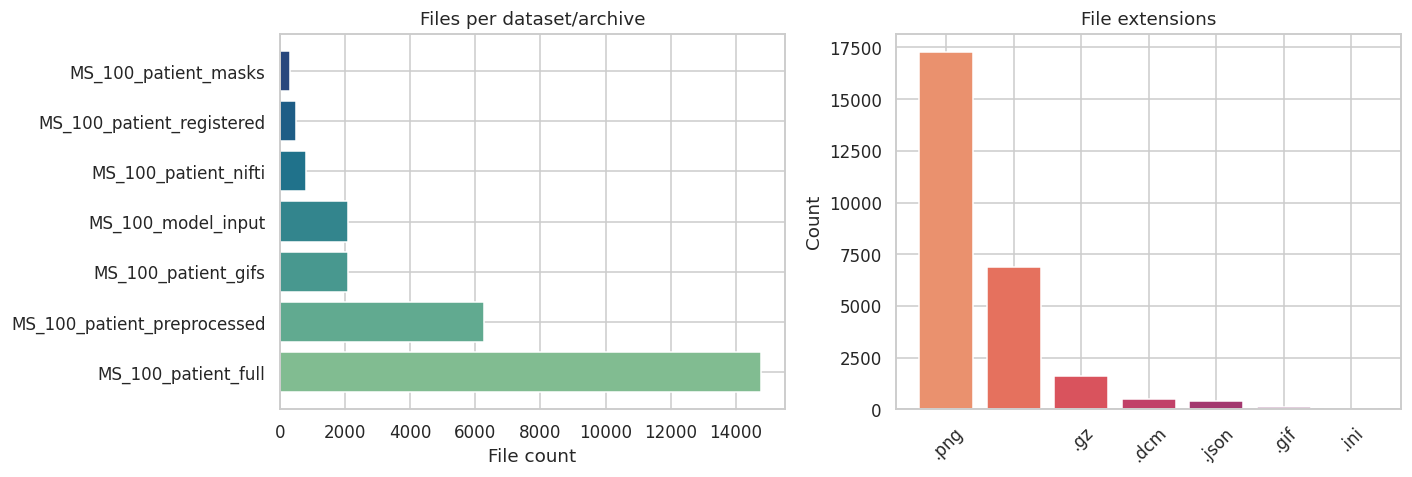

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

files_per_dataset = manifest["dataset"].value_counts()
axes[0].barh(files_per_dataset.index, files_per_dataset.values, color=sns.color_palette("crest", len(files_per_dataset)))
axes[0].set_title("Files per dataset/archive")
axes[0].set_xlabel("File count")

ext_counts = manifest["ext"].value_counts().head(10)
axes[1].bar(ext_counts.index, ext_counts.values, color=sns.color_palette("flare", len(ext_counts)))
axes[1].set_title("File extensions")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [10]:
patients_per_dataset = manifest.groupby("dataset")["patient_id"].nunique().sort_values(ascending=False)
print("Patients represented per dataset:")
print(patients_per_dataset)

# Patients with a full set (present in every dataset that has per-patient files)
patient_sets = manifest.groupby("dataset")["patient_id"].apply(set)
common_patients = set.intersection(*patient_sets) if len(patient_sets) else set()
print(f"\nPatients present across ALL extracted datasets: {len(common_patients)}")


Patients represented per dataset:
dataset
MS_100_model_input             101
MS_100_patient_gifs            101
MS_100_patient_masks           100
MS_100_patient_preprocessed    100
MS_100_patient_nifti           100
MS_100_patient_registered      100
MS_100_patient_full             94
Name: patient_id, dtype: int64

Patients present across ALL extracted datasets: 93


## 5. NIfTI metadata inspection

Load a handful of NIfTI volumes and inspect shape, voxel spacing, orientation, and affine —
essential sanity checks before any modeling, since inconsistent spacing/orientation across
patients silently breaks most pipelines.


In [11]:
nifti_files = manifest[manifest["ext"].isin([".nii", ".gz"])].copy()
nifti_files = nifti_files[nifti_files["filename"].str.endswith((".nii", ".nii.gz"))]
sample_files = nifti_files.sample(min(8, len(nifti_files)), random_state=42) if len(nifti_files) else nifti_files

meta_rows = []
for _, row in sample_files.iterrows():
    try:
        img = nib.load(row["path"])
        hdr = img.header
        zooms = hdr.get_zooms()
        meta_rows.append({
            "patient_id": row["patient_id"],
            "dataset": row["dataset"],
            "filename": row["filename"],
            "shape": img.shape,
            "voxel_spacing_mm": tuple(round(z, 3) for z in zooms[:3]),
            "orientation": "".join(nib.aff2axcodes(img.affine)),
            "dtype": str(img.get_data_dtype()),
        })
    except Exception as e:
        meta_rows.append({"patient_id": row["patient_id"], "filename": row["filename"], "error": str(e)})

meta_df = pd.DataFrame(meta_rows)
meta_df


,patient_id,dataset,filename,shape,voxel_spacing_mm,orientation,dtype
0,P048,MS_100_patient_nifti,048_T2WI.nii.gz,"(704, 704, 15)","(0.327, 0.327, 8.3)",LAS,int16
1,P010,MS_100_patient_masks,010_nWMH_Mask.nii.gz,"(256, 256, 20)","(0.898, 0.898, 6.4)",LAS,int16
2,P091,MS_100_patient_masks,091_abWMH_Mask.nii.gz,"(256, 256, 20)","(0.898, 0.898, 7.2)",LAS,int16
3,P080,MS_100_patient_masks,080_abWMH_Mask.nii.gz,"(256, 256, 20)","(0.898, 0.898, 7.2)",LAS,int16
4,P006,MS_100_patient_preprocessed,006_FLAIR.nii.gz,"(256, 256, 20)","(0.898, 0.898, 7.9)",LAS,int16
5,P039,MS_100_patient_registered,039_FLAIR_brain.nii.gz,"(256, 256, 20)","(0.898, 0.898, 7.2)",LAS,float32
6,P060,MS_100_patient_registered,060_FLAIR.nii.gz,"(256, 256, 18)","(0.898, 0.898, 7.2)",LAS,int16
7,P093,MS_100_patient_masks,093_Vent_Mask.nii.gz,"(256, 256, 20)","(0.898, 0.898, 6.4)",LAS,int16


## 6. Intensity statistics

Voxel-intensity distributions per patient — useful for spotting scanner/protocol differences
that would need harmonization (e.g. bias-field variation, contrast differences) before
modeling.


In [12]:
def load_volume(path):
    img = nib.load(path)
    return img.get_fdata(), img

intensity_stats = []
hist_data = {}

for _, row in sample_files.iterrows():
    try:
        vol, _ = load_volume(row["path"])
        nz = vol[vol > 0]  # ignore background zeros
        intensity_stats.append({
            "patient_id": row["patient_id"],
            "mean": nz.mean(), "std": nz.std(),
            "p01": np.percentile(nz, 1), "p99": np.percentile(nz, 99),
            "min": nz.min(), "max": nz.max(),
        })
        hist_data[row["patient_id"]] = nz
    except Exception as e:
        print(f"skip {row['filename']}: {e}")

intensity_df = pd.DataFrame(intensity_stats)
intensity_df


,patient_id,mean,std,p01,p99,min,max
0,P048,1486.036122,2005.291341,9.00000,8651.000000,1.000000,16383.000000
1,P010,255.000000,0.000000,255.00000,255.000000,255.000000,255.000000
2,P091,255.000000,0.000000,255.00000,255.000000,255.000000,255.000000
3,P080,255.000000,0.000000,255.00000,255.000000,255.000000,255.000000
4,P006,1760.486682,2582.583873,11.87268,11186.934979,0.042665,16383.000179
5,P039,4090.115702,1177.454872,489.00000,6677.790000,1.000000,13961.000000
6,P060,1722.406658,2510.260524,13.00000,11032.710000,1.000000,16382.000000
7,P093,1.000000,0.000000,1.00000,1.000000,1.000000,1.000000


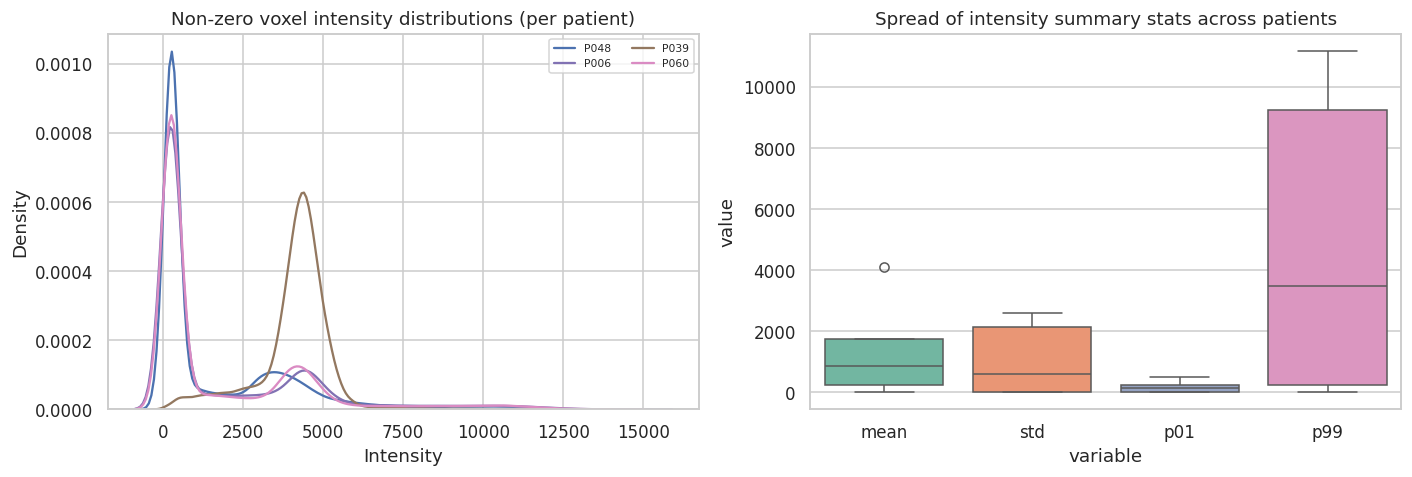

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for pid, vals in hist_data.items():
    sample_vals = RNG.choice(vals, size=min(50000, len(vals)), replace=False)
    sns.kdeplot(sample_vals, ax=axes[0], label=pid, fill=False)
axes[0].set_title("Non-zero voxel intensity distributions (per patient)")
axes[0].set_xlabel("Intensity")
axes[0].legend(fontsize=7, ncol=2)

if len(intensity_df):
    melted = intensity_df.melt(id_vars="patient_id", value_vars=["mean", "std", "p01", "p99"])
    sns.boxplot(data=melted, x="variable", y="value", ax=axes[1], palette="Set2")
    axes[1].set_title("Spread of intensity summary stats across patients")

plt.tight_layout()
plt.show()


## 7. Multi-planar slice visualization

Standard radiological views — axial, sagittal, coronal — for one example patient, taken at
the mid-slice of each axis.


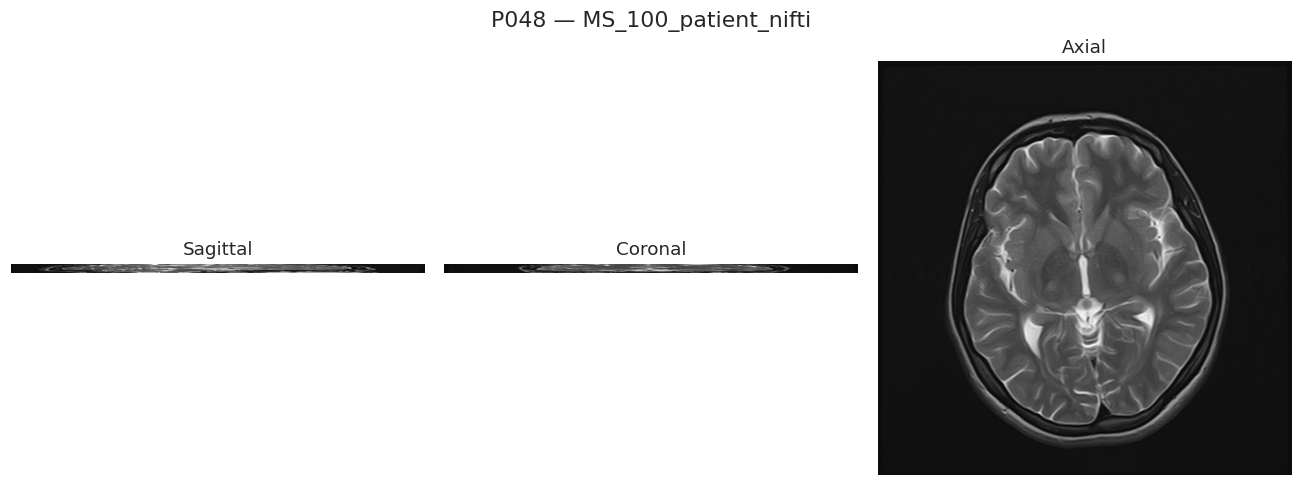

In [14]:
def show_orthogonal(vol, title="", cmap="gray"):
    x, y, z = [s // 2 for s in vol.shape]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
    axes[0].imshow(np.rot90(vol[x, :, :]), cmap=cmap); axes[0].set_title("Sagittal")
    axes[1].imshow(np.rot90(vol[:, y, :]), cmap=cmap); axes[1].set_title("Coronal")
    axes[2].imshow(np.rot90(vol[:, :, z]), cmap=cmap); axes[2].set_title("Axial")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if len(sample_files):
    example_row = sample_files.iloc[0]
    example_vol, _ = load_volume(example_row["path"])
    show_orthogonal(example_vol, title=f"{example_row['patient_id']} — {example_row['dataset']}")


## 8. Multi-patient QC montage

A quick-look grid of the same axial slice fraction across many patients — the fastest way to
spot registration failures, corrupted volumes, or obvious outliers before deeper analysis.


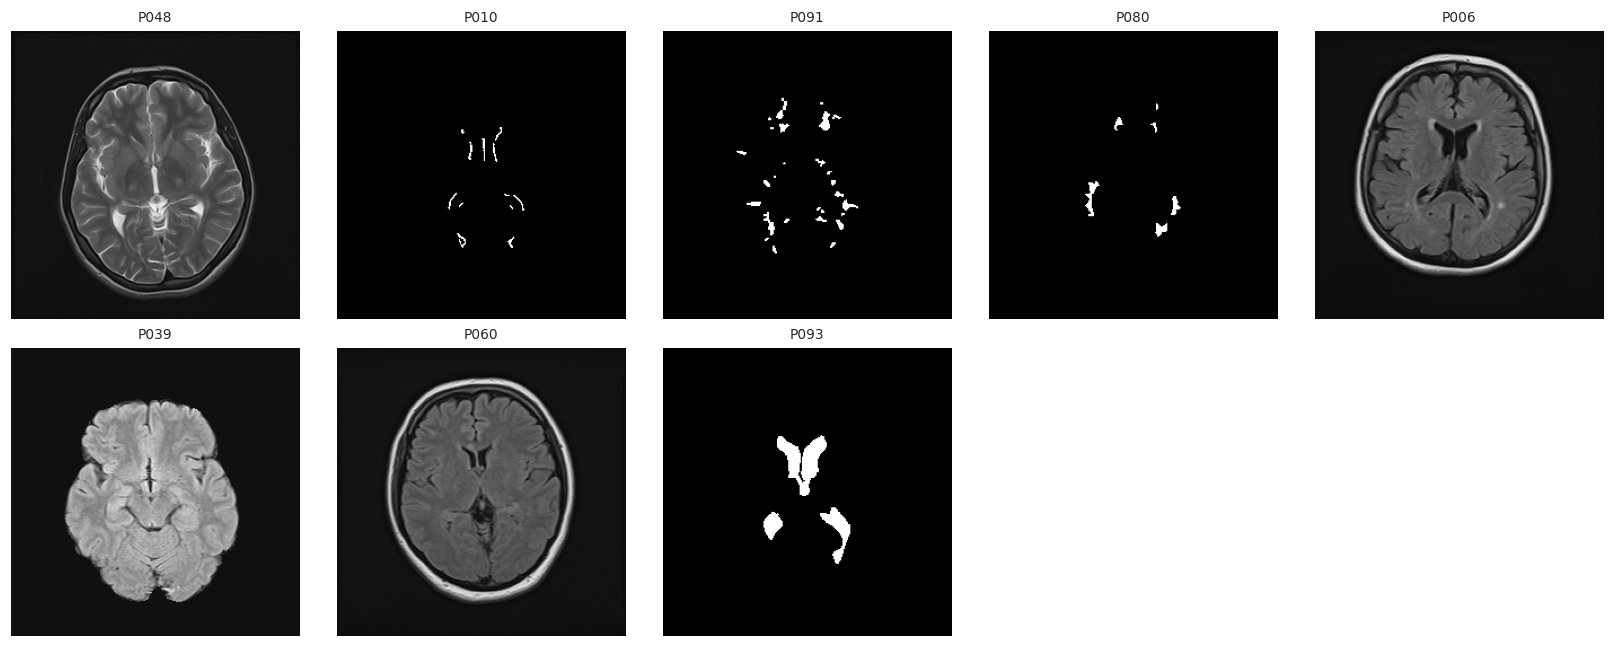

In [15]:
def montage(paths_labels, slice_frac=0.5, cols=5, cmap="gray"):
    n = len(paths_labels)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_2d(axes)
    for i, (path, label) in enumerate(paths_labels):
        r, c = divmod(i, cols)
        try:
            vol, _ = load_volume(path)
            z = int(vol.shape[2] * slice_frac)
            axes[r, c].imshow(np.rot90(vol[:, :, z]), cmap=cmap)
        except Exception:
            axes[r, c].text(0.5, 0.5, "load failed", ha="center", va="center")
        axes[r, c].set_title(label, fontsize=9)
        axes[r, c].axis("off")
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

montage_inputs = [(r["path"], r["patient_id"]) for _, r in sample_files.iterrows()]
if montage_inputs:
    montage(montage_inputs)


## 9. Lesion mask overlays

Overlay lesion segmentation masks (from `MS_100_patient_masks.rar`) on the matching MRI
volume to visually verify lesion locations, before any volume/count quantification.


In [16]:
mask_files = manifest[manifest["is_mask"]].copy()
print(f"Mask files found: {len(mask_files)}")
mask_files.head()


Mask files found: 400


,dataset,patient_id,filename,path,ext,size_mb,is_mask
18928,MS_100_patient_masks,P077,077_abWMH_Mask.nii.gz,/content/ms_data/extracted/MS_100_patient_mask...,.gz,0.012675,True
18929,MS_100_patient_masks,P052,052_abWMH_Mask.nii.gz,/content/ms_data/extracted/MS_100_patient_mask...,.gz,0.013222,True
18930,MS_100_patient_masks,P033,033_abWMH_Mask.nii.gz,/content/ms_data/extracted/MS_100_patient_mask...,.gz,0.013846,True
18931,MS_100_patient_masks,P076,076_abWMH_Mask.nii.gz,/content/ms_data/extracted/MS_100_patient_mask...,.gz,0.015377,True
18932,MS_100_patient_masks,P064,064_abWMH_Mask.nii.gz,/content/ms_data/extracted/MS_100_patient_mask...,.gz,0.012512,True


In [17]:
def overlay_mask(vol, mask, slice_idx=None, axis=2, alpha=0.45, title=""):
    if slice_idx is None:
        # pick the slice with the most lesion voxels for a meaningful view
        lesion_per_slice = mask.sum(axis=tuple(a for a in range(3) if a != axis))
        slice_idx = int(np.argmax(lesion_per_slice))
    sl = [slice(None)] * 3
    sl[axis] = slice_idx
    img_slice = np.rot90(vol[tuple(sl)])
    mask_slice = np.rot90(mask[tuple(sl)])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img_slice, cmap="gray")
    masked = np.ma.masked_where(mask_slice == 0, mask_slice)
    ax.imshow(masked, cmap="autumn", alpha=alpha)
    ax.set_title(f"{title} (slice {slice_idx})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Try to pair one mask with its corresponding MRI volume by patient_id
if len(mask_files) and len(nifti_files):
    example_mask_row = mask_files.iloc[0]
    pid = example_mask_row["patient_id"]
    candidate_vols = nifti_files[(nifti_files["patient_id"] == pid) & (~nifti_files["is_mask"])]
    if len(candidate_vols):
        vol, _ = load_volume(candidate_vols.iloc[0]["path"])
        mask, _ = load_volume(example_mask_row["path"])
        mask = (mask > 0).astype(np.uint8)
        if vol.shape == mask.shape:
            overlay_mask(vol, mask, title=f"{pid} lesion overlay")
        else:
            print(f"Shape mismatch: vol {vol.shape} vs mask {mask.shape} — check registration/resampling.")
    else:
        print(f"No matching MRI volume found for mask patient {pid} in current sample.")


Shape mismatch: vol (512, 512, 18) vs mask (256, 256, 18) — check registration/resampling.


## 10. Lesion volume quantification

Compute lesion volume (voxel count × voxel volume in mm³, converted to mL) per patient from
the mask files, and look at how lesion burden is distributed across the cohort — this is
often the single most clinically meaningful summary statistic in MS imaging studies.


In [18]:
lesion_volume_rows = []
for _, row in mask_files.iterrows():
    try:
        img = nib.load(row["path"])
        data = img.get_fdata()
        mask = (data > 0)
        zooms = img.header.get_zooms()[:3]
        voxel_vol_mm3 = np.prod(zooms)
        lesion_ml = mask.sum() * voxel_vol_mm3 / 1000.0
        lesion_volume_rows.append({"patient_id": row["patient_id"], "lesion_volume_ml": lesion_ml,
                                    "voxel_count": int(mask.sum())})
    except Exception as e:
        print(f"skip {row['filename']}: {e}")

lesion_df = pd.DataFrame(lesion_volume_rows).drop_duplicates("patient_id")
lesion_df = lesion_df.sort_values("lesion_volume_ml", ascending=False)
lesion_df


,patient_id,lesion_volume_ml,voxel_count
69,P044,48.286911,7670
66,P029,47.925004,8732
93,P089,44.299408,7623
67,P008,39.731254,6311
13,P040,39.271925,6007
...,...,...,...
74,P054,0.999541,172
53,P056,0.934971,181
18,P086,0.750624,155
54,P010,0.315101,61


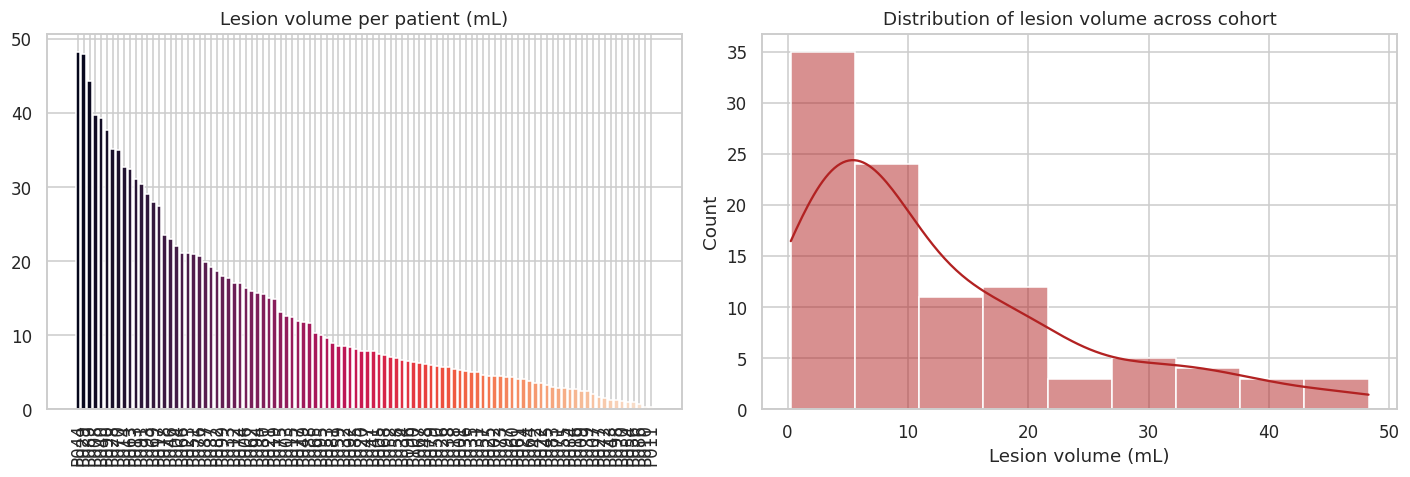

In [19]:
if len(lesion_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].bar(lesion_df["patient_id"], lesion_df["lesion_volume_ml"], color=sns.color_palette("rocket", len(lesion_df)))
    axes[0].set_title("Lesion volume per patient (mL)")
    axes[0].tick_params(axis="x", rotation=90)

    sns.histplot(lesion_df["lesion_volume_ml"], kde=True, ax=axes[1], color="firebrick")
    axes[1].set_title("Distribution of lesion volume across cohort")
    axes[1].set_xlabel("Lesion volume (mL)")

    plt.tight_layout()
    plt.show()


## 11. Lesion connected-component analysis

Beyond total lesion volume, MS burden is also characterized by lesion **count** and
**individual lesion size distribution** (many small lesions vs. few large confluent ones is
clinically distinct).


In [20]:
component_rows = []
per_lesion_sizes = []

for _, row in mask_files.iterrows():
    try:
        img = nib.load(row["path"])
        data = (img.get_fdata() > 0).astype(np.uint8)
        zooms = img.header.get_zooms()[:3]
        voxel_vol_mm3 = np.prod(zooms)
        labeled, n_components = ndi.label(data)
        sizes = ndi.sum(data, labeled, range(1, n_components + 1)) * voxel_vol_mm3 / 1000.0  # mL
        component_rows.append({"patient_id": row["patient_id"], "n_lesions": n_components,
                                "mean_lesion_size_ml": sizes.mean() if n_components else 0,
                                "max_lesion_size_ml": sizes.max() if n_components else 0})
        for s in sizes:
            per_lesion_sizes.append({"patient_id": row["patient_id"], "lesion_size_ml": s})
    except Exception as e:
        print(f"skip {row['filename']}: {e}")

component_df = pd.DataFrame(component_rows)
lesion_sizes_df = pd.DataFrame(per_lesion_sizes)
component_df


,patient_id,n_lesions,mean_lesion_size_ml,max_lesion_size_ml
0,P077,35,0.340209,2.411682
1,P052,34,0.207860,1.297611
2,P033,45,0.393618,7.984702
3,P076,58,0.356292,1.632970
4,P064,20,0.190610,0.923994
...,...,...,...,...
395,P071,1,1577.536336,1577.536336
396,P019,1,1385.603490,1385.603490
397,P073,1,1396.229907,1396.229907
398,P084,1,1377.217290,1377.217290


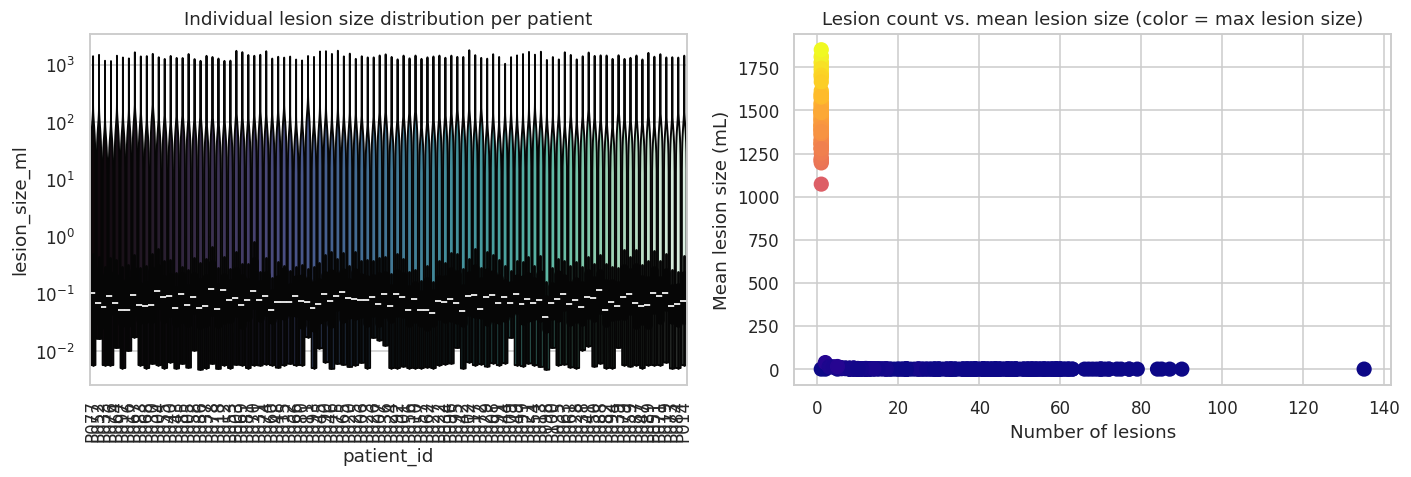

In [21]:
if len(lesion_sizes_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    sns.violinplot(data=lesion_sizes_df, x="patient_id", y="lesion_size_ml", ax=axes[0], palette="mako", cut=0)
    axes[0].set_title("Individual lesion size distribution per patient")
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].set_yscale("log")

    axes[1].scatter(component_df["n_lesions"], component_df["mean_lesion_size_ml"],
                     s=80, c=component_df["max_lesion_size_ml"], cmap="plasma")
    axes[1].set_xlabel("Number of lesions")
    axes[1].set_ylabel("Mean lesion size (mL)")
    axes[1].set_title("Lesion count vs. mean lesion size (color = max lesion size)")

    plt.tight_layout()
    plt.show()


## 12. Population-level lesion probability heatmap

**Requires masks to already be spatially registered to a common template** (this is what
the `_registered` archive is for). Averaging masks voxel-wise across patients produces a
lesion-frequency map — bright regions are where lesions most commonly occur across the
cohort, a classic MS-imaging visualization.


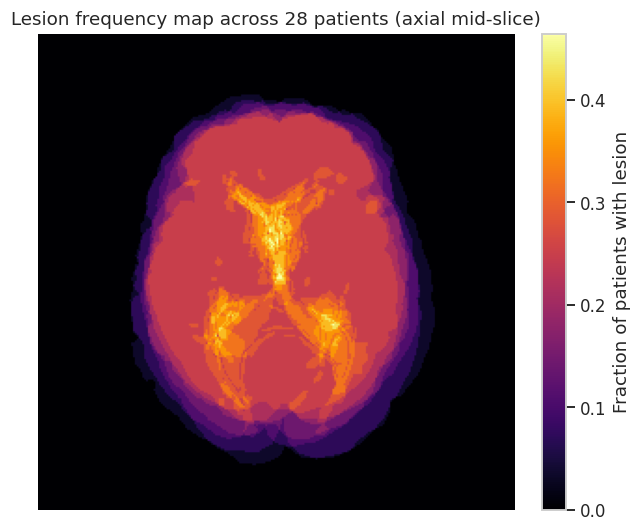

In [22]:
registered_mask_candidates = mask_files.copy()
loaded_masks = []
ref_shape = None
for _, row in registered_mask_candidates.iterrows():
    try:
        img = nib.load(row["path"])
        data = (img.get_fdata() > 0).astype(np.float32)
        if ref_shape is None:
            ref_shape = data.shape
        if data.shape == ref_shape:
            loaded_masks.append(data)
    except Exception:
        continue

if len(loaded_masks) >= 2:
    prob_map = np.mean(np.stack(loaded_masks, axis=0), axis=0)
    z = prob_map.shape[2] // 2
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(np.rot90(prob_map[:, :, z]), cmap="inferno")
    ax.set_title(f"Lesion frequency map across {len(loaded_masks)} patients (axial mid-slice)")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, label="Fraction of patients with lesion")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough same-shape masks loaded in this sample to build a probability map. "
          "Load more patients, or confirm masks come from the co-registered set.")


## 13. 3D lesion surface rendering

An interactive 3D mesh of one patient's lesion mask via marching cubes — much more
informative than 2D slices for understanding lesion shape and spatial distribution.


In [23]:
if len(mask_files):
    example_mask_row = mask_files.iloc[0]
    img = nib.load(example_mask_row["path"])
    mask = (img.get_fdata() > 0).astype(np.uint8)

    if mask.sum() > 0:
        verts, faces, normals, values = measure.marching_cubes(mask, level=0.5)
        fig = go.Figure(data=[go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color="crimson", opacity=0.6,
        )])
        fig.update_layout(
            title=f"3D lesion surface — {example_mask_row['patient_id']}",
            scene=dict(aspectmode="data"),
            width=650, height=550,
        )
        fig.show()
    else:
        print("Empty mask in this sample — try a different mask file for 3D rendering.")


## 14. Precomputed GIF previews

The dataset ships pre-rendered GIF previews (`MS_100_patient_gifs.*`) — likely animated
slice-scrolls per patient. Display a few directly rather than regenerating them.


GIFs found: 100
P077 077_animated.gif


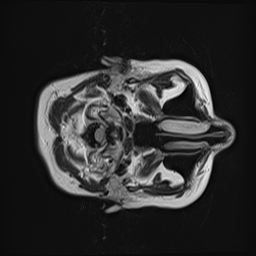

P052 052_animated.gif


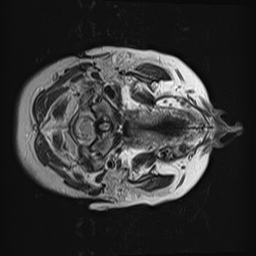

P033 033_animated.gif


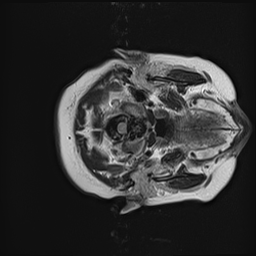

In [24]:
gif_files = manifest[manifest["ext"] == ".gif"]
print(f"GIFs found: {len(gif_files)}")

for _, row in gif_files.head(3).iterrows():
    print(row["patient_id"], row["filename"])
    display(IPyImage(filename=row["path"]))


## 15. Correlation & statistical analysis

Combine the per-patient summary features computed above (lesion volume, lesion count, mean
lesion size, intensity stats) into one table and look at how they relate to each other.


In [25]:
summary_df = lesion_df.merge(component_df, on="patient_id", how="outer")
if len(intensity_df):
    summary_df = summary_df.merge(intensity_df[["patient_id", "mean", "std"]], on="patient_id", how="outer")
summary_df = summary_df.set_index("patient_id")
summary_df


,lesion_volume_ml,voxel_count,n_lesions,mean_lesion_size_ml,max_lesion_size_ml,mean,std
patient_id,,,,,,,
P001,5.340246,973,26,0.205394,1.816672,NaN,NaN
P001,5.340246,973,12,1.807524,19.440033,NaN,NaN
P001,5.340246,973,46,0.163818,1.196479,NaN,NaN
P001,5.340246,973,1,1490.570815,1490.570815,NaN,NaN
P002,4.530621,693,33,0.137292,0.719146,NaN,NaN
...,...,...,...,...,...,...,...
P099,17.977202,3228,1,1586.510375,1586.510375,NaN,NaN
P100,6.427279,1106,59,0.108937,0.464903,NaN,NaN
P100,6.427279,1106,5,7.444253,35.105958,NaN,NaN


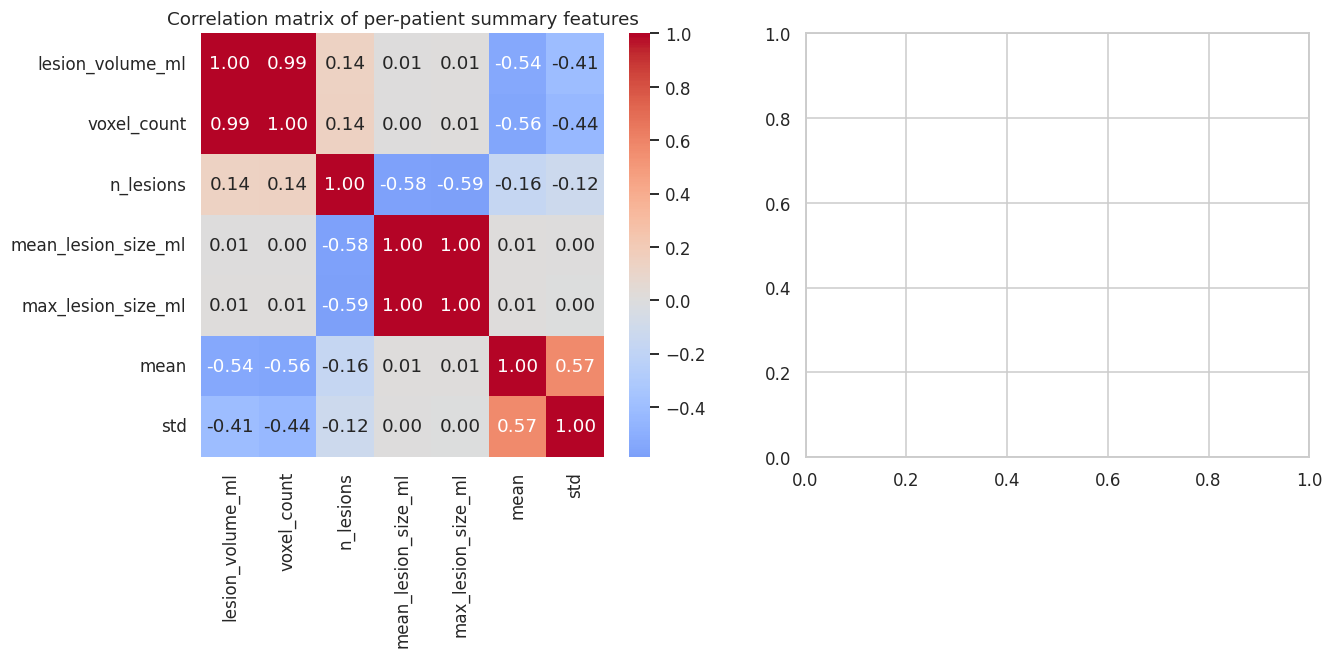

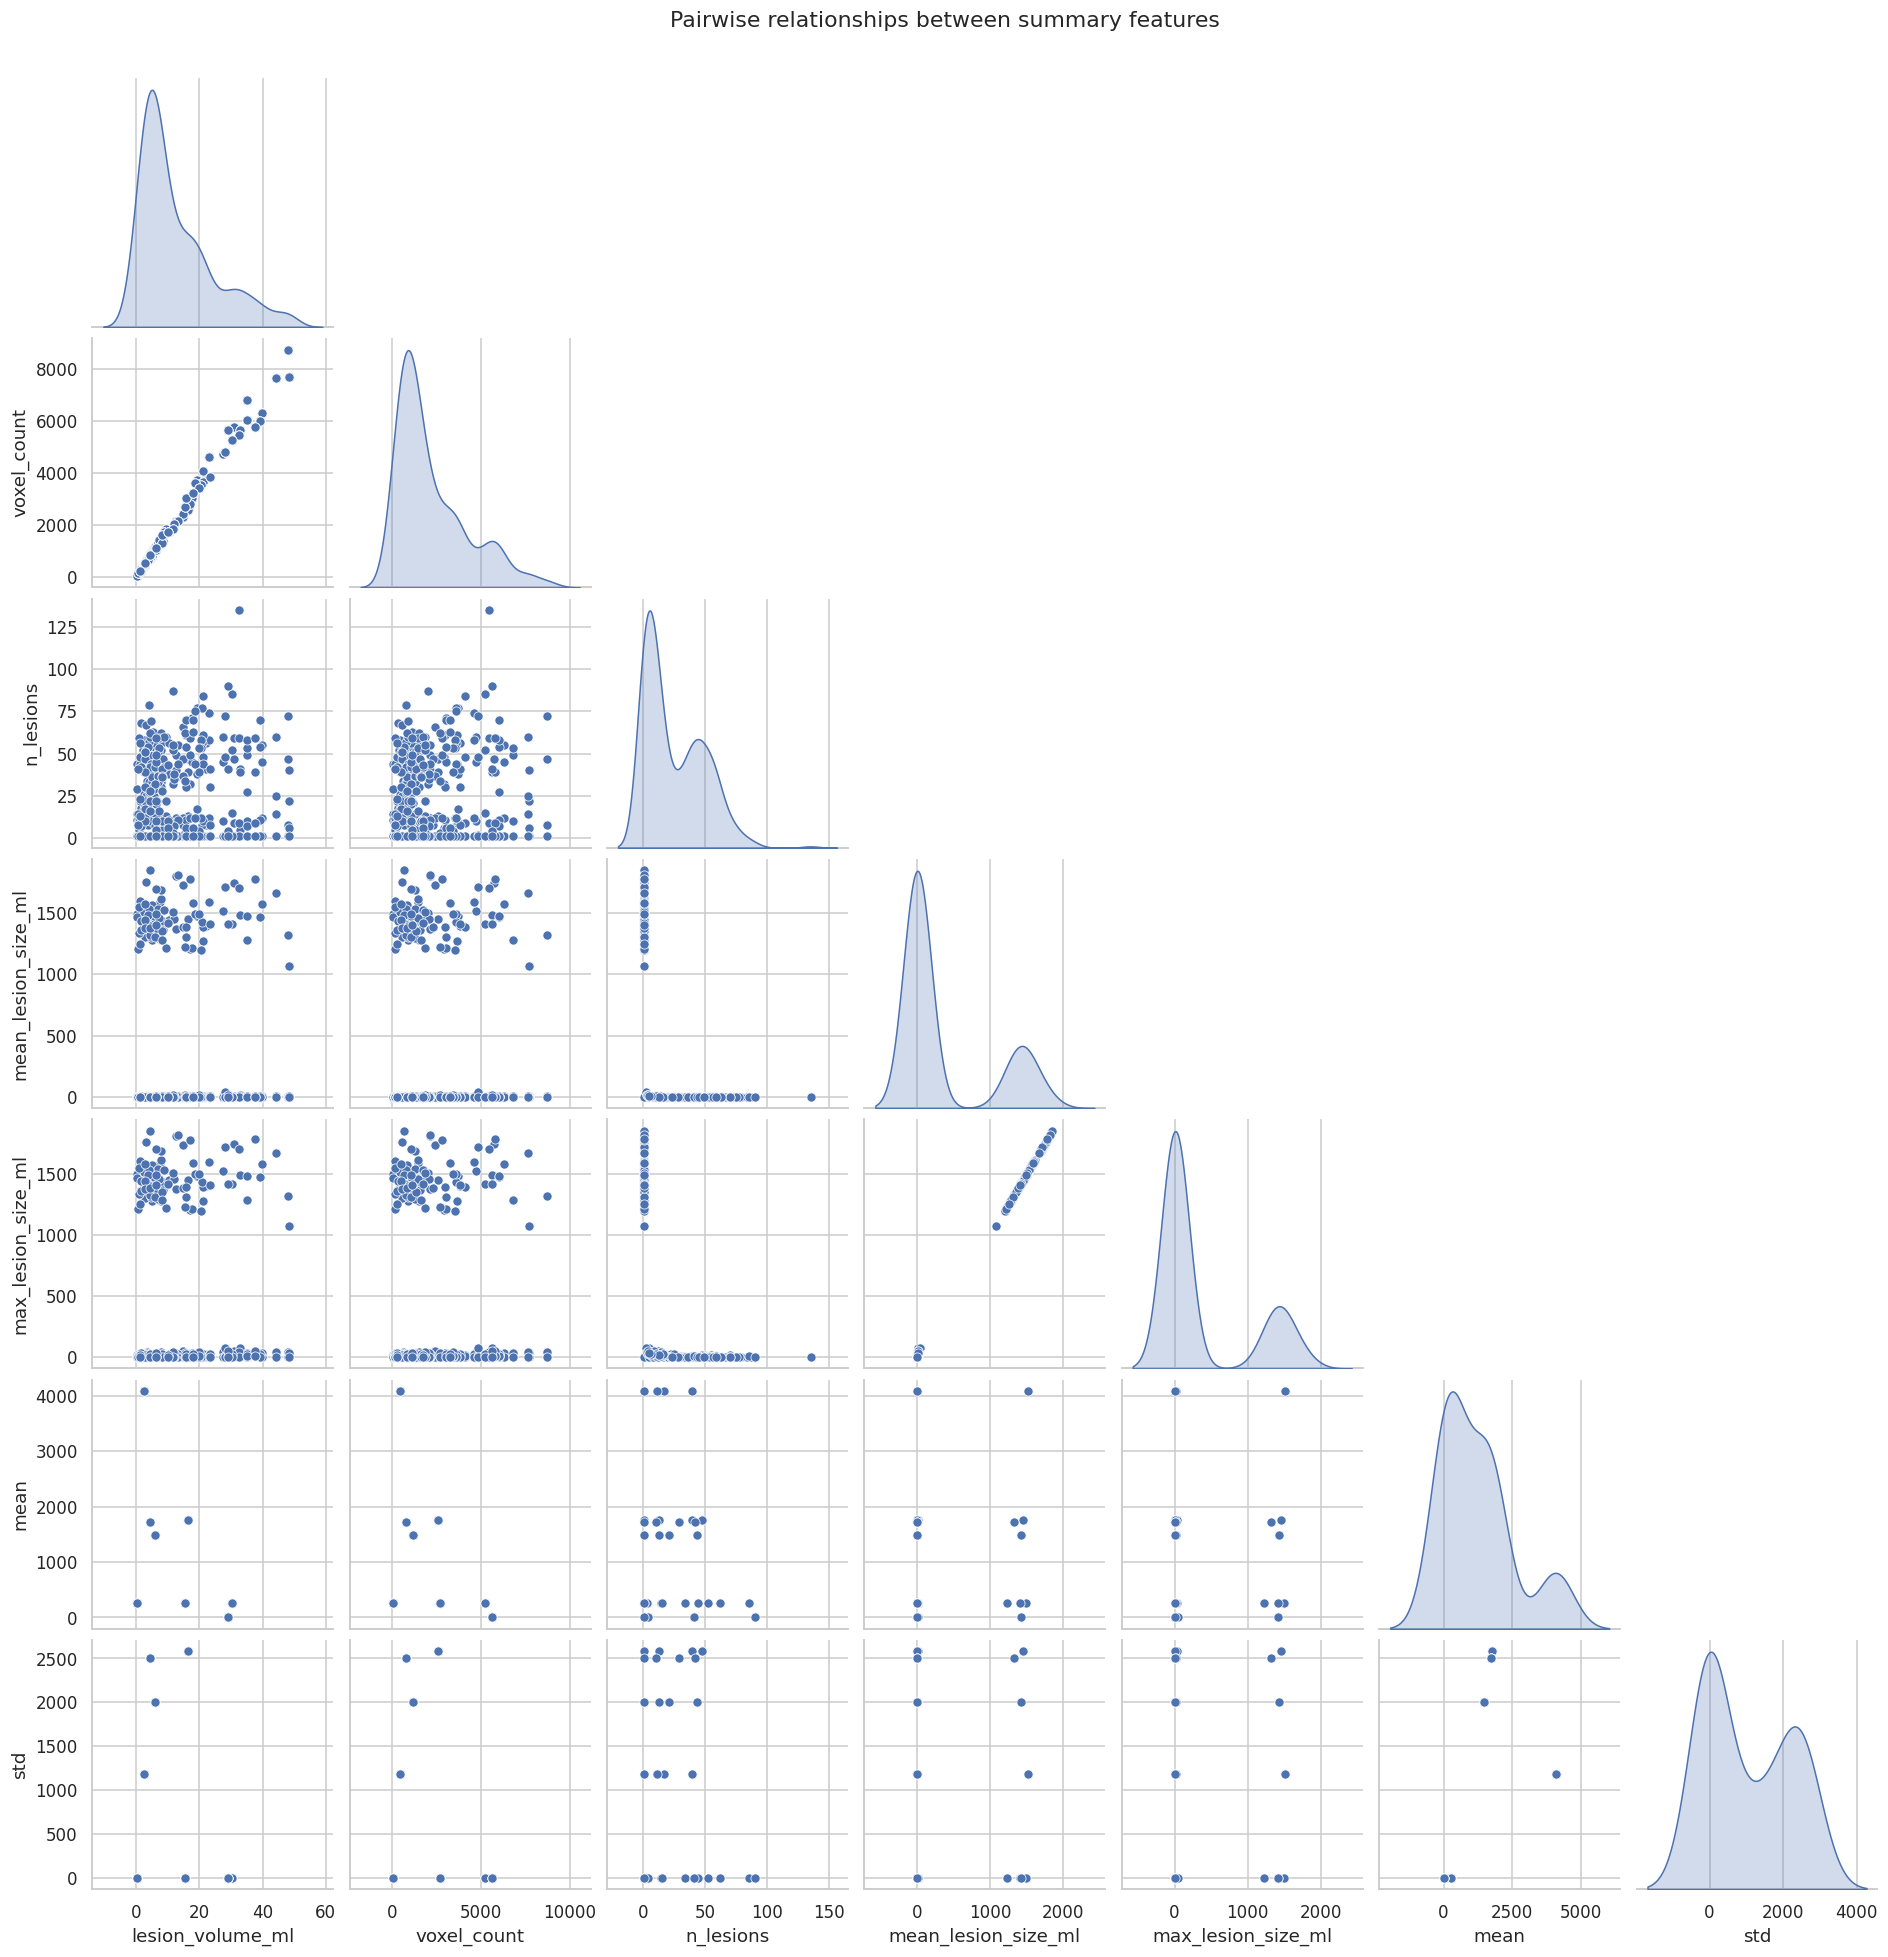

In [26]:
numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) >= 2 and len(summary_df) >= 3:
    corr = summary_df[numeric_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Correlation matrix of per-patient summary features")

    sns.pairplot(summary_df[numeric_cols].reset_index(drop=True), corner=True, diag_kind="kde")
    plt.suptitle("Pairwise relationships between summary features", y=1.02)
    plt.show()
else:
    print("Not enough numeric features / patients yet in this sample to compute correlations — "
          "increase the sample size in section 5/6 above.")


## 16. PCA of per-patient summary features

A 2D PCA projection of the summary feature table — useful for spotting patient clusters or
outliers (e.g. a patient with unusually high lesion burden separating from the rest).


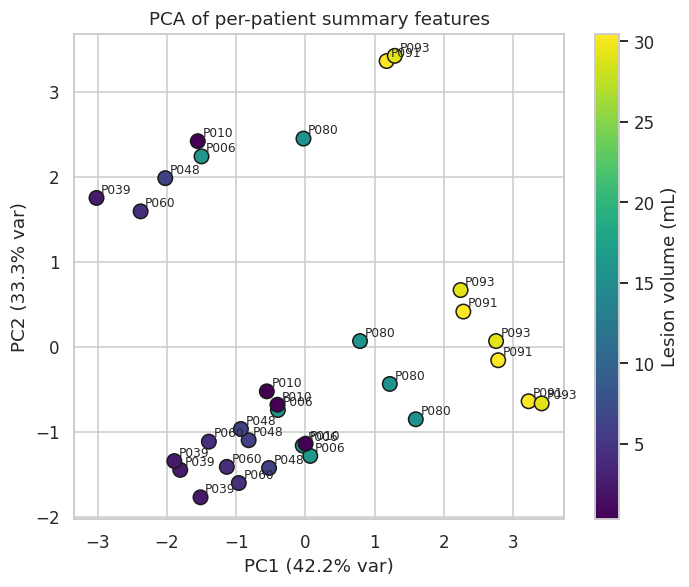

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_input = summary_df[numeric_cols].dropna()
if len(pca_input) >= 3 and pca_input.shape[1] >= 2:
    X = StandardScaler().fit_transform(pca_input.values)
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                     c=pca_input["lesion_volume_ml"] if "lesion_volume_ml" in pca_input else "steelblue",
                     cmap="viridis", s=90, edgecolor="k")
    for i, pid in enumerate(pca_input.index):
        ax.annotate(pid, (coords[i, 0], coords[i, 1]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    ax.set_title("PCA of per-patient summary features")
    if "lesion_volume_ml" in pca_input:
        plt.colorbar(sc, ax=ax, label="Lesion volume (mL)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough patients/features yet for a meaningful PCA — expand the sample size above.")


## 17. Interactive slice explorer widget

A live slider to scroll through axial slices of a chosen patient/volume — the fastest way to
"play with" a single volume interactively (this is what your supervisor likely means by
exploring the data hands-on).


In [28]:
if len(nifti_files):
    patient_options = sorted(nifti_files["patient_id"].unique().tolist())

    patient_dropdown = widgets.Dropdown(options=patient_options, description="Patient:")
    slice_slider = widgets.IntSlider(min=0, max=100, step=1, value=50, description="Slice %:")
    out = widgets.Output()

    def update_view(change=None):
        with out:
            out.clear_output(wait=True)
            rows = nifti_files[nifti_files["patient_id"] == patient_dropdown.value]
            if not len(rows):
                print("No volume for this patient in the current sample.")
                return
            vol, _ = load_volume(rows.iloc[0]["path"])
            z = int(vol.shape[2] * slice_slider.value / 100)
            z = min(max(z, 0), vol.shape[2] - 1)
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.imshow(np.rot90(vol[:, :, z]), cmap="gray")
            ax.set_title(f"{patient_dropdown.value} — axial slice {z}/{vol.shape[2]}")
            ax.axis("off")
            plt.show()

    patient_dropdown.observe(update_view, names="value")
    slice_slider.observe(update_view, names="value")
    display(widgets.HBox([patient_dropdown, slice_slider]), out)
    update_view()
else:
    print("No NIfTI volumes loaded in the current sample.")


Output()

## 18. Summary dashboard

A compact recap of the cohort-level statistics gathered above.


In [29]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total files indexed:         {len(manifest)}")
print(f"Datasets/archives extracted: {manifest['dataset'].nunique()}")
print(f"Patients seen (any dataset): {manifest['patient_id'].nunique()}")
if len(lesion_df):
    print(f"Mean lesion volume (mL):     {lesion_df['lesion_volume_ml'].mean():.2f}")
    print(f"Median lesion volume (mL):   {lesion_df['lesion_volume_ml'].median():.2f}")
    print(f"Max lesion volume (mL):      {lesion_df['lesion_volume_ml'].max():.2f}  "
          f"(patient {lesion_df.iloc[0]['patient_id'] if len(lesion_df) else '-'})")
if len(component_df):
    print(f"Mean lesion count/patient:   {component_df['n_lesions'].mean():.1f}")
print("=" * 60)
print("\nNext steps once EDA is reviewed with your supervisor:")
print(" - decide train/val/test split at the patient level (never split by slice)")
print(" - confirm which archive set (_registered vs _nifti vs _full) is canonical for modeling")
print(" - if segmentation is the goal: baseline U-Net using MS_100_model_input.rar as a starting point")


DATASET SUMMARY
Total files indexed:         26783
Datasets/archives extracted: 7
Patients seen (any dataset): 101
Mean lesion volume (mL):     12.73
Median lesion volume (mL):   7.88
Max lesion volume (mL):      48.29  (patient P044)
Mean lesion count/patient:   24.7

Next steps once EDA is reviewed with your supervisor:
 - decide train/val/test split at the patient level (never split by slice)
 - confirm which archive set (_registered vs _nifti vs _full) is canonical for modeling
 - if segmentation is the goal: baseline U-Net using MS_100_model_input.rar as a starting point


---
### Notes

- This notebook only loaded a **sample** of volumes (default 8) for speed while exploring —
  bump `sample_files = nifti_files.sample(...)` in Section 5 up to `nifti_files` (i.e. all of
  them) once you're ready for a full-cohort pass, but expect that to take a while given
  volume sizes and Colab RAM limits.
- The regex-based `guess_patient_id` and mask-detection (`is_mask`) heuristics in Section 3
  are a best guess from the archive/file names described in the shared folder — worth a quick
  manual check against a few filenames once the archives are actually extracted, and adjusted
  if patient IDs or mask-naming conventions differ from what's assumed here.
- Section 12 (population heatmap) only works if masks are voxel-aligned to a common
  space/template — that's presumably what `MS_100_patient_registered.rar` provides.
